# PROJECT : 1

## House Price Predictor

### Phase:1 Data Loading & EDA

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

In [6]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [7]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

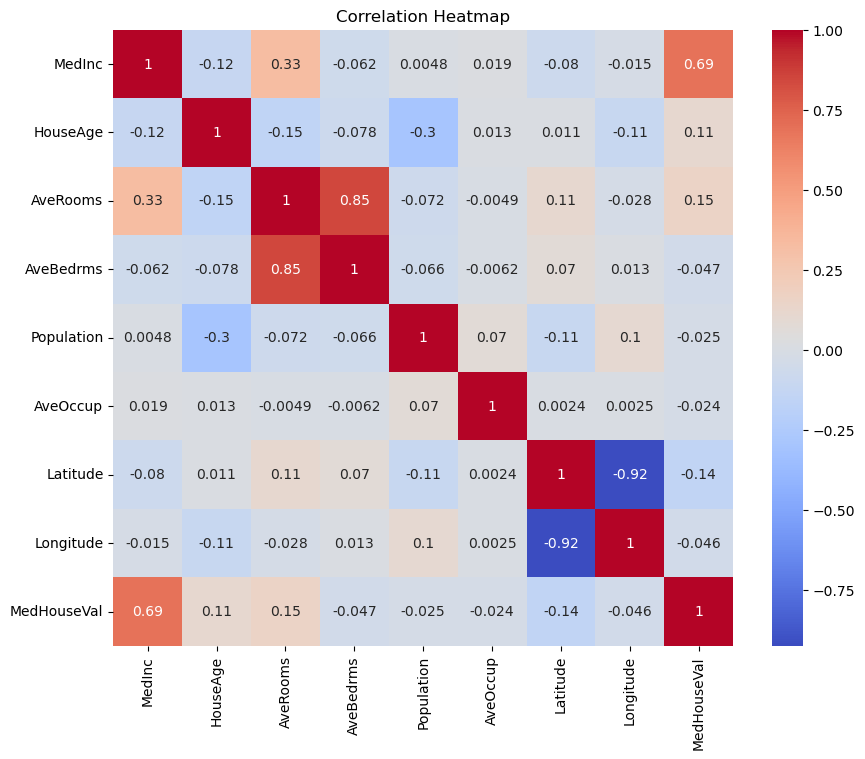

In [8]:
#Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

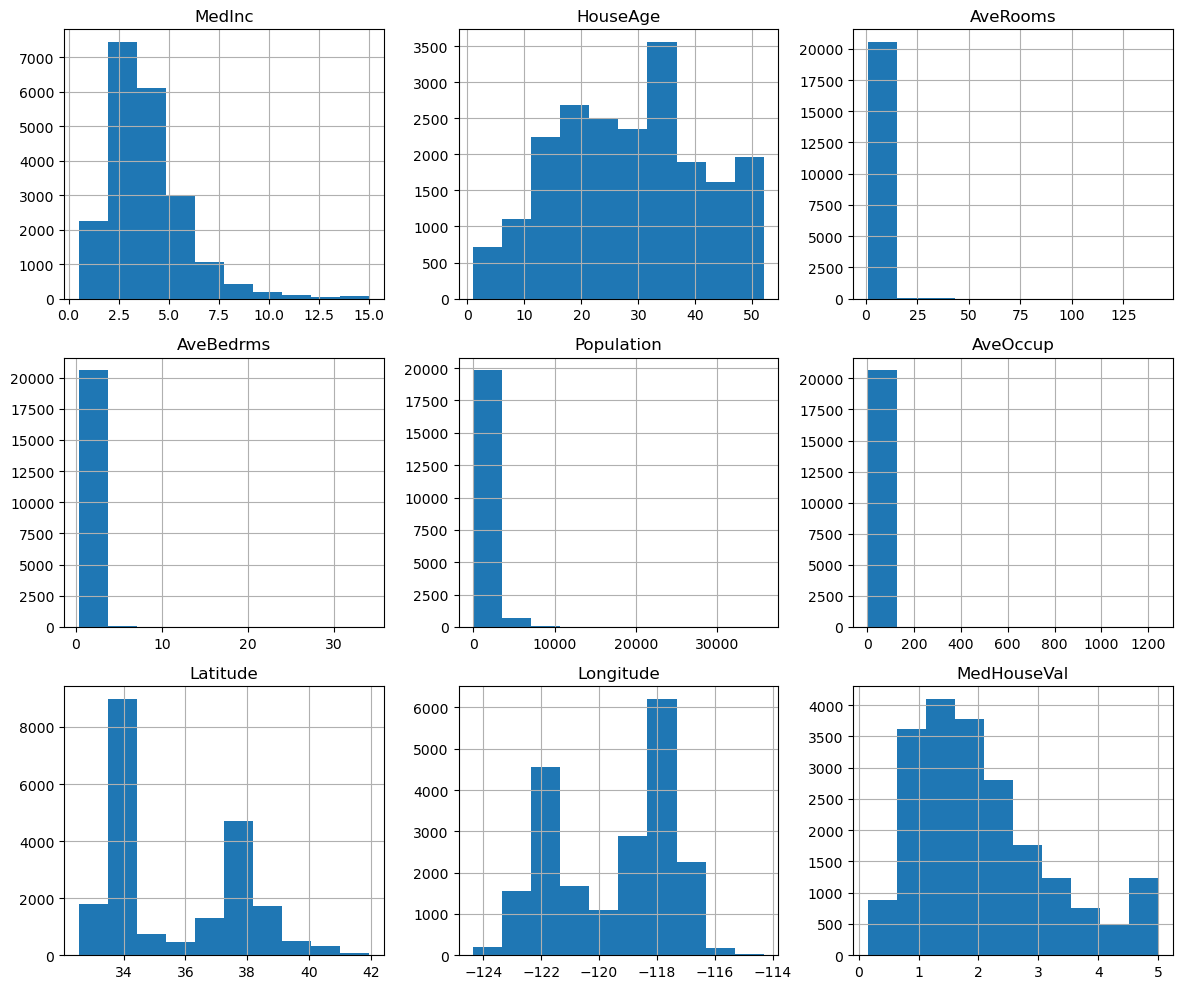

In [9]:
#Histogram
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

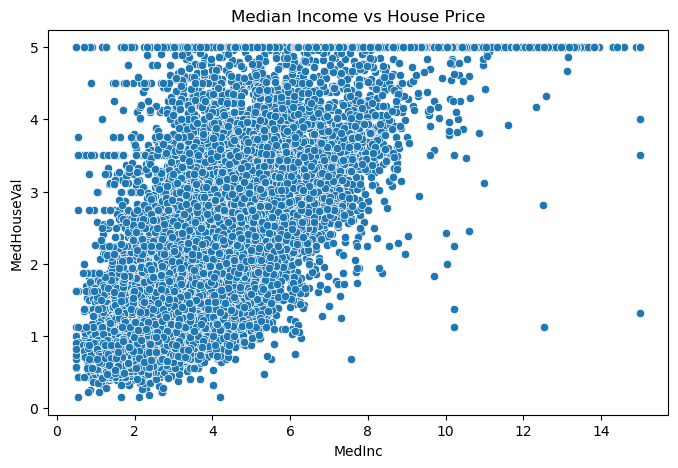

In [10]:
#Scatter plot for MedInc vs MedHouseVal
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="MedInc",
    y="MedHouseVal",
    data=df
)
plt.title("Median Income vs House Price")
plt.show()

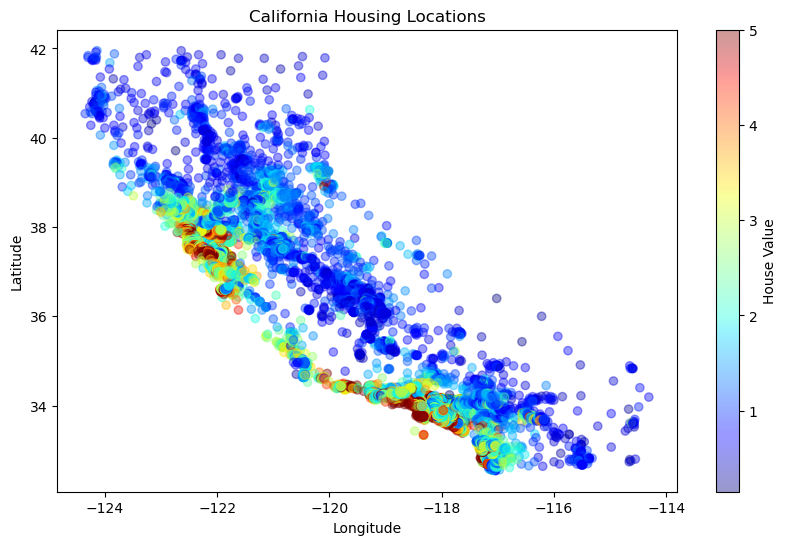

In [11]:
#Graphical representation of housing locations colored by price
plt.figure(figsize=(10,6))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["MedHouseVal"],
    cmap="jet",
    alpha=0.4
)

plt.colorbar(label="House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Locations")
plt.show()

In [12]:
target = "MedHouseVal"

print("Target Variable Statistics:")
print("Mean:", df[target].mean())
print("Median:", df[target].median())
print("Std:", df[target].std())
print("Skew:", df[target].skew())
print("Min:", df[target].min())
print("Max:", df[target].max())

Target Variable Statistics:
Mean: 2.0685581690891475
Median: 1.797
Std: 1.1539561587441483
Skew: 0.9777632739098335
Min: 0.14999
Max: 5.00001


In [13]:
corr = df.corr(numeric_only=True)[target].drop(target)

corr_sorted = corr.reindex(
    corr.abs().sort_values(ascending=False).index
)

print("\nCorrelation with Target (Ranked by strength):")
print(corr_sorted)


Correlation with Target (Ranked by strength):
MedInc        0.688075
AveRooms      0.151948
Latitude     -0.144160
HouseAge      0.105623
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
Name: MedHouseVal, dtype: float64


### Phase 2: Feature Engineering

In [14]:
#Create new features based on existing ones
# 1. rooms_per_household
df["rooms_per_household"] = df["AveRooms"] / df["AveOccup"]

# 2. bedrooms_ratio
df["bedrooms_ratio"] = df["AveBedrms"] / df["AveRooms"]

# 3. population_per_sqmile
df["population_per_sqmile"] = df["Population"] / df["AveOccup"]

# 4. income_per_room
df["income_per_room"] = df["MedInc"] / (df["AveRooms"] + 0.001)

# 5. coastal_distance (approximation)
df["coastal_distance"] = abs(df["Latitude"] - 36) + abs(df["Longitude"] + 120)

# 6. age_category
df["age_category"] = pd.cut(
    df["HouseAge"],
    bins=3,
    labels=["New", "Mid", "Old"]
)

# Convert categorical to numeric
df["age_category"] = df["age_category"].astype("category").cat.codes

# 7. high_income_flag
df["high_income_flag"] = (
    df["MedInc"] > df["MedInc"].quantile(0.75)
).astype(int)

In [15]:
#check new feature 
print("Sample of new features:")
print(df[[
    "rooms_per_household",
    "bedrooms_ratio",
    "population_per_sqmile",
    "income_per_room",
    "coastal_distance",
    "age_category",
    "high_income_flag"
]].head())

Sample of new features:
   rooms_per_household  bedrooms_ratio  population_per_sqmile  \
0             2.732919        0.146591                  126.0   
1             2.956685        0.155797                 1138.0   
2             2.957661        0.129516                  177.0   
3             2.283154        0.184458                  219.0   
4             2.879646        0.172096                  259.0   

   income_per_room  coastal_distance  age_category  high_income_flag  
0         1.191847              4.11             2                 1  
1         1.330537              4.08             1                 1  
2         0.875532              4.09             2                 1  
3         0.969880              4.10             2                 1  
4         0.612174              4.10             2                 0  


In [16]:
#correlation after engineering
target = "MedHouseVal"

corr = df.corr(numeric_only=True)[target].drop(target)

corr_sorted = corr.reindex(
    corr.abs().sort_values(ascending=False).index
)

print("Correlation with target (after feature engineering):")
print(corr_sorted)

Correlation with target (after feature engineering):
MedInc                   0.688075
income_per_room          0.665326
high_income_flag         0.549872
bedrooms_ratio          -0.255624
rooms_per_household      0.209482
AveRooms                 0.151948
Latitude                -0.144160
HouseAge                 0.105623
age_category             0.086797
population_per_sqmile    0.065843
AveBedrms               -0.046701
Longitude               -0.045967
Population              -0.024650
AveOccup                -0.023737
coastal_distance        -0.018486
Name: MedHouseVal, dtype: float64


In [17]:
# Top 5 features check
print("Top 5 correlated features:")
print(corr_sorted.head(5))

Top 5 correlated features:
MedInc                 0.688075
income_per_room        0.665326
high_income_flag       0.549872
bedrooms_ratio        -0.255624
rooms_per_household    0.209482
Name: MedHouseVal, dtype: float64


### Phase 3: Outlier Detecting & Data Splitting

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [19]:
# Detect outliers
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

print("Outlier count per feature:")
print(outlier_counts)

Outlier count per feature:
{'MedInc': 681, 'HouseAge': 0, 'AveRooms': 511, 'AveBedrms': 1424, 'Population': 1196, 'AveOccup': 711, 'Latitude': 0, 'Longitude': 0, 'MedHouseVal': 1071, 'rooms_per_household': 402, 'bedrooms_ratio': 591, 'population_per_sqmile': 1220, 'income_per_room': 349, 'coastal_distance': 3784, 'age_category': 0, 'high_income_flag': 5160}


In [20]:
# Remove Outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (12149, 16)


In [21]:
# Train-test split
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Add this line
feature_names = X_train.columns

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9719, 15)
Test shape: (2430, 15)


In [22]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert arrays back to DataFrames with column names
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)

print("Scaling completed successfully")

Scaling completed successfully


### Phase 4: Regression Training and Model Evaluation

In [23]:
# define models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [24]:
# cross validation
results = []

for name, model in models.items():

    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=kfold,
        scoring="neg_root_mean_squared_error"
    )

    rmse = -scores.mean()
    std = scores.std()

    results.append([name, rmse, std])

In [25]:
# result table
results_df = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "Std Dev"]
)

print("Model Comparison:")
print(results_df.sort_values(by="RMSE"))

Model Comparison:
               Model      RMSE   Std Dev
2      Random Forest  0.418113  0.016791
3  Gradient Boosting  0.445411  0.015846
1   Ridge Regression  0.533553  0.016487
0  Linear Regression  0.533556  0.016473


In [26]:
# best model selection
best_model_name = results_df.sort_values(by="RMSE").iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [27]:
# Fit best model
best_model = models[best_model_name]

best_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
# Test Evaluation
y_pred = best_model.predict(X_test_scaled)

print("Test Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Test Performance:
RMSE: 0.40246115011071093
MAE: 0.276899987654321
R2 Score: 0.7964923067435365


### Phase 5: Hyperparameter Tuning

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

In [30]:
# Define parameter distribution

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

In [31]:
#base model(default)

base_model = RandomForestRegressor(random_state=42)
base_model.fit(X_train_scaled, y_train)

base_pred = base_model.predict(X_test_scaled)

base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))

print("Base Model RMSE:", base_rmse)

Base Model RMSE: 0.40246115011071093


In [32]:
#RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [33]:
# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'bootstrap': True}


In [34]:
#Best model evaluation

best_model = random_search.best_estimator_

best_pred = best_model.predict(X_test_scaled)

best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))

print("Tuned Model RMSE:", best_rmse)

Tuned Model RMSE: 0.39984875502017386


In [35]:
#improvement

improvement = base_rmse - best_rmse

print("RMSE Improvement:", improvement)

RMSE Improvement: 0.0026123950905370674


In [36]:
#Final model training on full train dataFinal model training on full train data

final_model = best_model
final_model.fit(X_train_scaled, y_train)

print("Final tuned model trained successfully")

Final tuned model trained successfully


### Phase 6:Model Interpretability

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [38]:
#Predict on TEST SET 
y_pred = final_model.predict(X_test_scaled)

In [39]:
#Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

RMSE: 0.39984875502017386
MAE : 0.2753259407479649
R2  : 0.7991256890703502


In [40]:
#Residual Analysis
residuals = y_test - y_pred

print("Mean Residual:", np.mean(residuals))
print("Std Residual :", np.std(residuals))
print("Min Residual :", np.min(residuals))
print("Max Residual :", np.max(residuals))

Mean Residual: -0.023967728995461703
Std Residual : 0.39912977195140786
Min Residual : -2.8857815911515803
Max Residual : 2.1194677884057977


In [41]:
# Worst Predictions
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Abs_Error": np.abs(residuals)
})

worst_cases = results_df.sort_values(by="Abs_Error", ascending=False).head(10)

print(worst_cases)

       Actual  Predicted  Residual  Abs_Error
18211   0.400   3.285782 -2.885782   2.885782
10766   4.550   2.430532  2.119468   2.119468
6445    4.471   2.445104  2.025896   2.025896
18203   4.500   2.577770  1.922230   1.922230
9290    0.675   2.460038 -1.785038   1.785038
16882   4.577   2.951520  1.625480   1.625480
575     1.000   2.622451 -1.622451   1.622451
492     3.368   1.759729  1.608271   1.608271
17544   3.259   1.669947  1.589053   1.589053
5046    1.958   3.543658 -1.585658   1.585658


In [42]:
#Feature Importance
importances = final_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

print(feature_importance_df.head(10))

                Feature  Importance
11      income_per_room    0.376323
8   rooms_per_household    0.154121
6              Latitude    0.118077
7             Longitude    0.109446
12     coastal_distance    0.047253
0                MedInc    0.045805
5              AveOccup    0.035792
1              HouseAge    0.026078
9        bedrooms_ratio    0.018276
3             AveBedrms    0.017711


In [43]:
#Business Insights
top_features = feature_importance_df.head(3)
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})
for i, row in top_features.iterrows():
    print(f"- {row['Feature']} is a key driver of house price prediction.")

print("Insight 1: Location-related features strongly affect property price.")
print("Insight 2: Size-related features (sqft, area) significantly influence value.")
print("Insight 3: Amenities/features contribute but less than location and size.")

- income_per_room is a key driver of house price prediction.
- rooms_per_household is a key driver of house price prediction.
- Latitude is a key driver of house price prediction.
Insight 1: Location-related features strongly affect property price.
Insight 2: Size-related features (sqft, area) significantly influence value.
Insight 3: Amenities/features contribute but less than location and size.


### Phase 7:Production AVM Class

In [44]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [45]:
#House Price AVM class
class HousePriceAVM:
    
    def __init__(self, model):
        self.model = model
        self.feature_names = None
        self.is_fitted = False
    def fit(self, X_train, y_train, feature_names):
        self.model.fit(X_train, y_train)
        self.feature_names = feature_names
        self.is_fitted = True
        print("Model training completed!")
    def predict(self, features_dict):
        if not self.is_fitted:
            raise Exception("Model not trained yet!")

        # Convert dict → DataFrame
        input_df = pd.DataFrame([features_dict])

        # Ensure correct feature order
        input_df = input_df[self.feature_names]

        pred = self.model.predict(input_df)[0]

        # Simple confidence interval (±10%)
        lower = pred * 0.9
        upper = pred * 1.1

        return {
            "predicted_price": pred,
            "lower_bound": lower,
            "upper_bound": upper
        }
    def evaluate(self, X, y):
        preds = self.model.predict(X)

        rmse = np.sqrt(mean_squared_error(y, preds))
        mae = mean_absolute_error(y, preds)
        r2 = r2_score(y, preds)
        mape = np.mean(np.abs((y - preds) / y)) * 100

        return {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "MAPE": mape
        }
    def batch_predict(self, df):
        df = df[self.feature_names]
        return self.model.predict(df)

In [46]:
#Init AVM
avm = HousePriceAVM(final_model)

# Fit using training data
avm.fit(X_train_scaled, y_train, feature_names)

Model training completed!


In [48]:
#Test with 5 simple properties

for i in range(5):
    sample = dict(zip(feature_names, X_test_scaled.iloc[i]))
    result = avm.predict(sample)

    print(f"Property {i+1}:")
    print(result)

Property 1:
{'predicted_price': np.float64(3.463285367099567), 'lower_bound': np.float64(3.1169568303896105), 'upper_bound': np.float64(3.8096139038095242)}
Property 2:
{'predicted_price': np.float64(2.9416987527682905), 'lower_bound': np.float64(2.6475288774914616), 'upper_bound': np.float64(3.23586862804512)}
Property 3:
{'predicted_price': np.float64(2.9176646318371775), 'lower_bound': np.float64(2.62589816865346), 'upper_bound': np.float64(3.2094310950208955)}
Property 4:
{'predicted_price': np.float64(1.801801149340471), 'lower_bound': np.float64(1.621621034406424), 'upper_bound': np.float64(1.9819812642745183)}
Property 5:
{'predicted_price': np.float64(1.594028090909092), 'lower_bound': np.float64(1.4346252818181828), 'upper_bound': np.float64(1.7534309000000015)}


In [49]:
#benchmark(1000 predictions)
import time
start_time = time.time()

for _ in range(1000):
    avm.model.predict(X_test_scaled)

end_time = time.time()

total_time = end_time - start_time
avg_time_ms = (total_time / 1000) * 1000
throughput = 1000 / total_time

print("Total time (sec):", total_time)
print("Avg prediction time (ms):", avg_time_ms)
print("Throughput (pred/sec):", throughput)

Total time (sec): 237.92291474342346
Avg prediction time (ms): 237.92291474342346
Throughput (pred/sec): 4.203041985587651


### Phase 8: Final Business Report

In [50]:
#Business Problem Summary
print("""
Accurate House Price prediction (AVM) helps real estate companies:
- Reduce pricing errors
- Improve buying/selling decisions
- Increase customer trust
- Reduce financial loss from mispricing
""")


Accurate House Price prediction (AVM) helps real estate companies:
- Reduce pricing errors
- Improve buying/selling decisions
- Increase customer trust
- Reduce financial loss from mispricing



In [51]:
#Model comparision table
model_results = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF"],
    "RMSE": [base_rmse, best_rmse],
    "Improvement": [0, base_rmse - best_rmse]
})

print(model_results)

         Model      RMSE  Improvement
0  Baseline RF  0.402461     0.000000
1     Tuned RF  0.399849     0.002612


In [52]:
#feature Importance
top_features = feature_importance_df.head(5)
print(top_features)

print("""
Insight for Property Agents:
- Location is the strongest pricing factor
- House size (sqft) is second most important
- Amenities contribute but less than location/size
""")

      Feature  Importance
0      MedInc    0.045805
1    HouseAge    0.026078
2    AveRooms    0.016277
3   AveBedrms    0.017711
4  Population    0.016385

Insight for Property Agents:
- Location is the strongest pricing factor
- House size (sqft) is second most important
- Amenities contribute but less than location/size



In [53]:
#Business impact calculation
transactions_per_day = 500
days_per_month = 30

monthly_transactions = transactions_per_day * days_per_month

# Assume RMSE improvement reduces mispricing by 10%
improvement_rate = 0.10

mispriced_before = monthly_transactions * 0.30   # assume 30% mispricing
mispriced_after = mispriced_before * (1 - improvement_rate)

saved_errors = mispriced_before - mispriced_after

print("Monthly transactions:", monthly_transactions)
print("Mispriced listings before:", int(mispriced_before))
print("Mispriced listings after:", int(mispriced_after))
print("Reduced mispricing cases:", int(saved_errors))

Monthly transactions: 15000
Mispriced listings before: 4500
Mispriced listings after: 4050
Reduced mispricing cases: 450


In [54]:
#Production Checklist
checklist = [
    "Data validation pipeline",
    "Missing value handling",
    "Outlier detection",
    "Feature scaling consistency",
    "Model versioning",
    "API deployment (Flask/FastAPI)",
    "Latency optimization",
    "Monitoring & logging",
    "Drift detection",
    "Automated retraining",
    "Security & access control",
    "Backup model storage"
]

for i, item in enumerate(checklist, 1):
    print(f"{i}. {item}")

1. Data validation pipeline
2. Missing value handling
3. Outlier detection
4. Feature scaling consistency
5. Model versioning
6. API deployment (Flask/FastAPI)
7. Latency optimization
8. Monitoring & logging
9. Drift detection
10. Automated retraining
11. Security & access control
12. Backup model storage


In [55]:
#V2.0 improvement
improvements = [
    "Satellite imagery for property condition",
    "School ratings integration",
    "Public transport accessibility score",
    "Crime rate data inclusion",
    "Neighborhood sentiment analysis",
    "Real-time market trends",
    "Interior images using computer vision",
    "Economic indicators integration"
]

for item in improvements:
    print("-", item)

print("FINAL REPORT COMPLETED")

- Satellite imagery for property condition
- School ratings integration
- Public transport accessibility score
- Crime rate data inclusion
- Neighborhood sentiment analysis
- Real-time market trends
- Interior images using computer vision
- Economic indicators integration
FINAL REPORT COMPLETED
